<a href="https://colab.research.google.com/github/Layaa-V/MLOps-LayaaVishwakarma-M25CSA017/blob/Assignment-1/Assignment_1_MLops.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Q1(a) -

In [ ]:
!pip install thop

  Using cached torch-2.8.0-cp39-cp39-manylinux_2_28_x86_64.whl.metadata (30 kB)
  Using cached triton-3.4.0-cp39-cp39-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
Using cached torch-2.8.0-cp39-cp39-manylinux_2_28_x86_64.whl (888.0 MB)
Using cached triton-3.4.0-cp39-cp39-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (155.4 MB)
  Attempting uninstall: triton
    Found existing installation: triton 2.2.0
    Uninstalling triton-2.2.0:
      Successfully uninstalled triton-2.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torch]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import pandas as pd
import time
from sklearn import svm
from sklearn.metrics import accuracy_score
import warnings
from thop import profile
warnings.filterwarnings("ignore")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = True

In [ ]:
def get_dataloaders(dataset_name, batch_size, pin_memory):
    transform = transforms.Compose([
        transforms.Resize((64, 64)), # Compatibility resize
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    if dataset_name == 'MNIST':
        full_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    else:
        full_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    train_ds = Subset(full_data, range(0, 49000))
    val_ds = Subset(full_data, range(49000, 56000))

    # Setting num_workers=0 to avoid RuntimeError: Numpy is not available in DataLoader worker process
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=pin_memory, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, pin_memory=pin_memory, num_workers=0)
    test_loader = DataLoader(test_data, batch_size=batch_size, pin_memory=pin_memory, num_workers=0)

    return train_loader, val_loader, test_loader

In [ ]:
def initialize_model(model_name):
    if model_name == "ResNet-18":
        model = models.resnet18(pretrained=False)
    else:
        model = models.resnet50(pretrained=False)

    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(device)

In [ ]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    # Get the device of the model
    model_device = next(model.parameters()).device
    with torch.no_grad():
        for images, labels in loader:
            # Move images and labels to the model's device
            images, labels = images.to(model_device), labels.to(model_device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

In [ ]:
batch_sizes = [16, 32]
optimizers_list = ["SGD", "Adam"]
learning_rates = [0.001, 0.0001]
models_list = ["ResNet-18", "ResNet-50"]

results = []

for model_name in models_list:
    for bs in batch_sizes:
        for opt_name in optimizers_list:
            for lr in learning_rates:

                train_loader, val_loader, test_loader = get_dataloaders('MNIST', bs, pin_memory=True)
                model = initialize_model(model_name).to(device)
                optimizer = optim.SGD(model.parameters(), lr=lr) if opt_name == "SGD" else optim.Adam(model.parameters(), lr=lr)
                scaler = GradScaler(enabled=USE_AMP)

                for epoch in range(6):
                    model.train()
                    for images, labels in train_loader:
                        images, labels = images.to(device), labels.to(device)
                        optimizer.zero_grad()
                        with autocast(enabled=USE_AMP):
                            outputs = model(images)
                            loss = nn.CrossEntropyLoss()(outputs, labels)
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                # Final Accuracy
                acc = evaluate(model, test_loader)
                results.append([bs, opt_name, lr, model_name, acc])


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]


In [ ]:
df_results = pd.DataFrame(results, columns=["Batch Size", "Optimizer", "Learning Rate", "Model", "Accuracy (%)"])

In [ ]:
df_results

,Batch Size,Optimizer,Learning Rate,Model,Accuracy (%)
0,16,SGD,0.0010,ResNet-18,98.87
1,16,SGD,0.0001,ResNet-18,95.27
2,16,Adam,0.0010,ResNet-18,99.39
3,16,Adam,0.0001,ResNet-18,99.13
4,32,SGD,0.0010,ResNet-18,98.34
5,32,SGD,0.0001,ResNet-18,92.51
6,32,Adam,0.0010,ResNet-18,99.36
7,32,Adam,0.0001,ResNet-18,99.10
8,16,SGD,0.0010,ResNet-50,98.59
9,16,SGD,0.0001,ResNet-50,89.31


## Q1(b) -

In [ ]:
def get_flattened_data(dataset_name):
    train_loader, _, test_loader = get_dataloaders(dataset_name, batch_size=60000, pin_memory=False)

    # Extract images and labels from the loaders
    train_images, train_labels = next(iter(train_loader))
    test_images, test_labels = next(iter(test_loader))

    # Flatten: (Batch, 1, 64, 64) -> (Batch, 4096)
    X_train = train_images.view(train_images.size(0), -1).numpy()
    y_train = train_labels.numpy()
    X_test = test_images.view(test_images.size(0), -1).numpy()
    y_test = test_labels.numpy()

    return X_train, y_train, X_test, y_test

In [ ]:
data = ['MNIST', 'FashionMNIST']
kernels = ['poly', 'rbf']
svm_results = []

for ds_name in data:
    X_train, y_train, X_test, y_test = get_flattened_data(ds_name)

    for ker in kernels:
        # Start timer for Training Time (in ms)
        start_time = time.time()

        clf = svm.SVC(kernel=ker, max_iter=1000)
        clf.fit(X_train[:10000], y_train[:10000])

        end_time = time.time()
        train_time_ms = (end_time - start_time) * 1000

        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred) * 100

        svm_results.append([ds_name, ker, acc, train_time_ms])

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.58MB/s]
100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.5MB/s]


In [ ]:
df_svm = pd.DataFrame(svm_results, columns=["Dataset", "Kernel", "Test Accuracy (%)", "Train Time (ms)"])

In [ ]:
df_svm

,Dataset,Kernel,Test Accuracy (%),Train Time (ms)
0,MNIST,poly,96.41,42719.347239
1,MNIST,rbf,96.45,60662.334919
2,FashionMNIST,poly,86.19,47858.946562
3,FashionMNIST,rbf,85.16,58355.738401


In [ ]:
df_svm

## Q2 -

In [ ]:
def compare_func():
    res = []

    #Required Variables
    compute_devices = ["GPU", "CPU"]
    models_to_test = ["ResNet-18", "ResNet-50"]
    optimizers_to_test = ["SGD", "Adam"]
    learning_rate = 0.001
    batch_size = 16
    num_epochs = 3

    for compute in compute_devices:

        current_device = torch.device("cuda" if compute == "GPU" and torch.cuda.is_available() else "cpu")

        for model_name in models_to_test:
            for opt_name in optimizers_to_test:
                train_loader, val_loader, test_loader = get_dataloaders('FashionMNIST', batch_size, pin_memory=True)

                # Initialize Model
                model = initialize_model(model_name).to(current_device)

                # Select Optimizer
                if opt_name == "SGD":
                    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
                else:
                    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

                scaler = torch.cuda.amp.GradScaler(enabled=(compute == "GPU"))

                # Lists to store epoch-wise metrics for the current run
                current_run_train_losses = []
                current_run_val_accuracies = []

                # TRAIN PHASE
                model.train()
                for epoch in range(num_epochs):
                    total_loss = 0
                    for images, labels in train_loader:
                        images, labels = images.to(current_device), labels.to(current_device)
                        optimizer.zero_grad()

                        with torch.cuda.amp.autocast(enabled=(compute == "GPU")):
                            outputs = model(images)
                            loss = nn.CrossEntropyLoss()(outputs, labels)

                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()
                        total_loss += loss.item()

                    avg_train_loss = total_loss / len(train_loader)
                    val_acc = evaluate(model, val_loader) # Evaluate on validation set

                    current_run_train_losses.append(avg_train_loss)
                    current_run_val_accuracies.append(val_acc)

                # MEASUREMENT PHASE (after all epochs)
                imgs, _ = next(iter(train_loader))
                imgs = imgs.to(current_device)
                flops, params = profile(model, inputs=(imgs[0:1], ), verbose=False)

                # Training Time
                model.train()
                if compute == "GPU": torch.cuda.synchronize()

                start_time = time.time()
                for i, (images, labels) in enumerate(train_loader):
                    if i >= 100:
                      break
                    images, labels = images.to(current_device), labels.to(current_device)
                    optimizer.zero_grad()
                    with torch.cuda.amp.autocast(enabled=(compute == "GPU")):
                        outputs = model(images)
                        loss = nn.CrossEntropyLoss()(outputs, labels)
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()

                if compute == "GPU": torch.cuda.synchronize()
                end_time = time.time()
                train_time_ms = (end_time - start_time) * 1000

                # Final Test Accuracy
                test_acc = evaluate(model, test_loader)

                res.append({
                    "Compute": compute,
                    "Batch Size": batch_size,
                    "Optimizer": opt_name,
                    "Learning Rate": learning_rate,
                    "Model": model_name,
                    "Test Accuracy (%)": test_acc,
                    "Train Time (ms)": train_time_ms,
                    "FLOPs": flops,
                    "Epoch Train Losses": current_run_train_losses,
                    "Epoch Val Accuracies": current_run_val_accuracies
                })

    return pd.DataFrame(res)

In [ ]:
df_2 = compare_func()

In [ ]:
df_2

,Compute,Batch Size,Optimizer,Learning Rate,Model,Test Accuracy (%),Train Time (ms),FLOPs,Epoch Train Losses,Epoch Val Accuracies
0,GPU,16,SGD,0.001,ResNet-18,87.64,2239.423513,142441984.0,"[0.714519836020711, 0.3605178730416991, 0.2983...","[84.97142857142858, 86.81428571428572, 88.9285..."
1,GPU,16,Adam,0.001,ResNet-18,88.65,2287.928343,142441984.0,"[0.4178486344542256, 0.29147775053316344, 0.24...","[88.71428571428571, 90.84285714285714, 90.3714..."
2,GPU,16,SGD,0.001,ResNet-50,80.92,4807.822227,330881024.0,"[1.193396229025705, 0.6279746351938134, 0.4805...","[76.28571428571429, 80.52857142857142, 83.1714..."
3,GPU,16,Adam,0.001,ResNet-50,84.77,4548.972845,330881024.0,"[0.5446768844371872, 0.37096173615674355, 0.32...","[86.44285714285714, 86.02857142857142, 88.0714..."
4,CPU,16,SGD,0.001,ResNet-18,87.77,9764.726877,142441984.0,"[0.7126720017913779, 0.35902445557686263, 0.29...","[85.28571428571429, 86.95714285714286, 87.8142..."
5,CPU,16,Adam,0.001,ResNet-18,89.48,11360.593557,142441984.0,"[0.4161986341566781, 0.2924269067634802, 0.241...","[88.67142857142858, 89.55714285714286, 91.2857..."
6,CPU,16,SGD,0.001,ResNet-50,78.84,18040.843010,330881024.0,"[1.2402261954252136, 0.6517252721661082, 0.498...","[76.37142857142857, 78.34285714285714, 83.4428..."
7,CPU,16,Adam,0.001,ResNet-50,74.02,21231.782675,330881024.0,"[0.5446753949802606, 0.37271983429869815, 0.31...","[86.41428571428571, 88.04285714285714, 87.6285..."


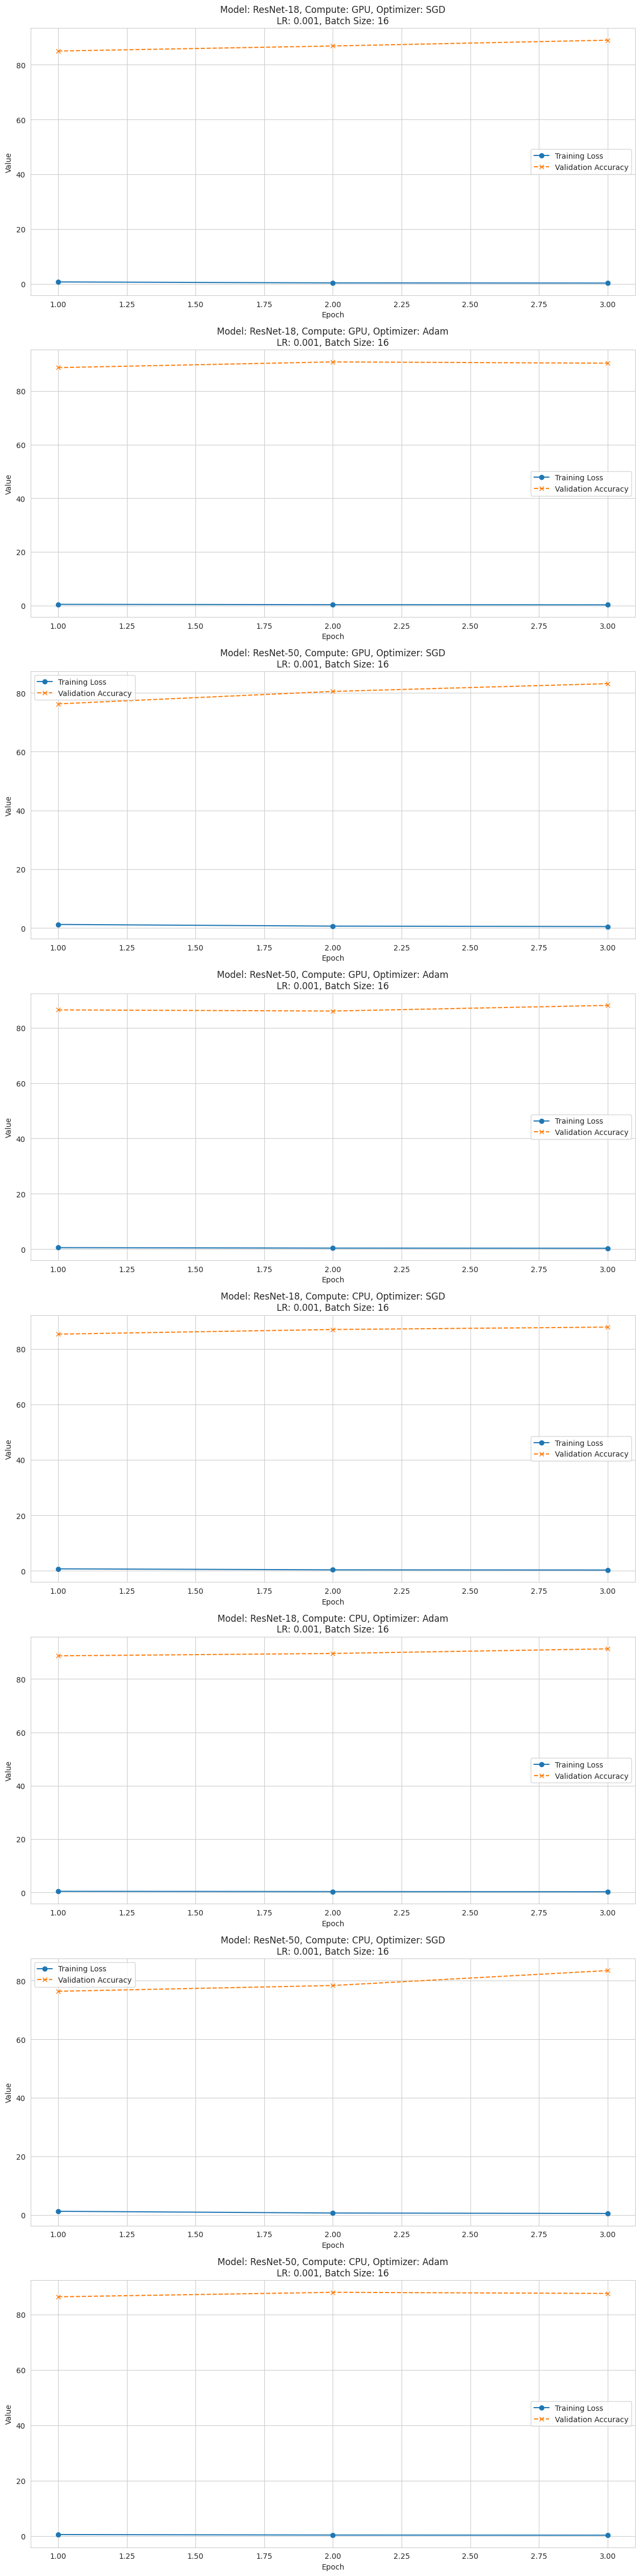

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(len(df_2), 1, figsize=(12, 6 * len(df_2)))

if len(df_2) == 1:
    axes = [axes]

for i, row in df_2.iterrows():
    epochs = range(1, len(row['Epoch Train Losses']) + 1)

    # Plot Training Loss
    axes[i].plot(epochs, row['Epoch Train Losses'], label='Training Loss', marker='o', linestyle='-')
    # Plot Validation Accuracy
    axes[i].plot(epochs, row['Epoch Val Accuracies'], label='Validation Accuracy', marker='x', linestyle='--')

    axes[i].set_title(f"Model: {row['Model']}, Compute: {row['Compute']}, Optimizer: {row['Optimizer']}\nLR: {row['Learning Rate']}, Batch Size: {row['Batch Size']}")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Value")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()